In [1]:
a=[1,2,3,4]
a

[1, 2, 3, 4]

In [3]:
print(a)

[1, 2, 3, 4]


In [5]:
print(type(a))


<class 'list'>


In [7]:
b=(1,2,"tuple","vansh")
b

(1, 2, 'tuple', 'vansh')

In [9]:
print(type(b))

<class 'tuple'>


In [11]:
import cv2

# Load Haar Cascade classifiers
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")

# Start webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        # Draw rectangle on face
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Region of interest for eyes
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        # Detect eyes
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=5)

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # Show output
    cv2.imshow("Face and Eye Detection", frame)

    # Press Q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\objdetect\src\cascadedetect.cpp:1689: error: (-215:Assertion failed) !empty() in function 'cv::CascadeClassifier::detectMultiScale'


In [13]:
pip install opencv-python imutils


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25857 sha256=cf08e3f26a4c8c6e38e99dde34d8480784c5996d26c8237eabbbac173b804103
  Stored in directory: c:\users\asus\appdata\local\pip\cache\wheels\5b\76\96\ad0c321506837bef578cf3008df3916c23018435a355d9f6b1
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import imutils
from IPython.display import display, clear_output
from PIL import Image
import time

# Load cascades
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")

cap = cv2.VideoCapture(0)

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Camera not working")
            break

        frame = imutils.resize(frame, width=600)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x,y), (x+w,y+h), (255,0,0), 2)

            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5)
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex,ey), (ex+ew,ey+eh), (0,255,0), 2)

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(rgb)

        clear_output(wait=True)
        display(img)
        time.sleep(0.03)

except KeyboardInterrupt:
    print("Stopped")

finally:
    cap.release()


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\objdetect\src\cascadedetect.cpp:1689: error: (-215:Assertion failed) !empty() in function 'cv::CascadeClassifier::detectMultiScale'


In [3]:
import cv2

face = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
eye = cv2.CascadeClassifier("haarcascade_eye.xml")

print("Face Loaded:", not face.empty())
print("Eye Loaded:", not eye.empty())


Face Loaded: False
Eye Loaded: False


In [5]:
import cv2

for i in range(5):
    cap = cv2.VideoCapture(i)
    print(f"Camera index {i} opened:", cap.isOpened())
    cap.release()


Camera index 0 opened: True
Camera index 1 opened: False
Camera index 2 opened: False
Camera index 3 opened: False
Camera index 4 opened: False


In [7]:
cap = cv2.VideoCapture(0)   # or 1 / 2 based on result


In [9]:
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")


In [11]:
import cv2

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

print("Face Loaded:", not face_cascade.empty())
print("Eye Loaded:", not eye_cascade.empty())


Face Loaded: True
Eye Loaded: True


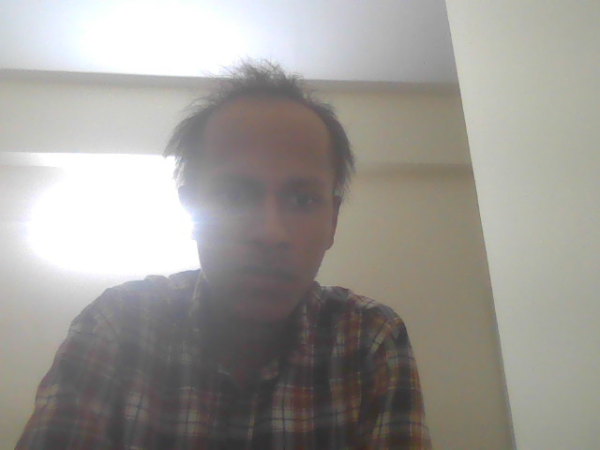

In [ ]:
import cv2
import imutils
from IPython.display import display, clear_output
from PIL import Image
import time

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera not accessible")
        break

    frame = imutils.resize(frame, width=600)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x,y,w,h) in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray,1.1,5)
        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(rgb)

    clear_output(wait=True)
    display(img)
    time.sleep(0.03)


In [ ]:
Kernel → Interrupt


In [ ]:
Ctrl + C


In [ ]:
print("Camera:", cap.isOpened())
print("Face:", not face_cascade.empty())
print("Eye:", not eye_cascade.empty())


In [1]:
import cv2

# Load Haarcascade classifiers
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# Start webcam
cap = cv2.VideoCapture(0)

print("Press 'q' to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera not accessible")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        # Detect eyes
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5)

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    cv2.imshow("Face and Eye Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Press 'q' to quit


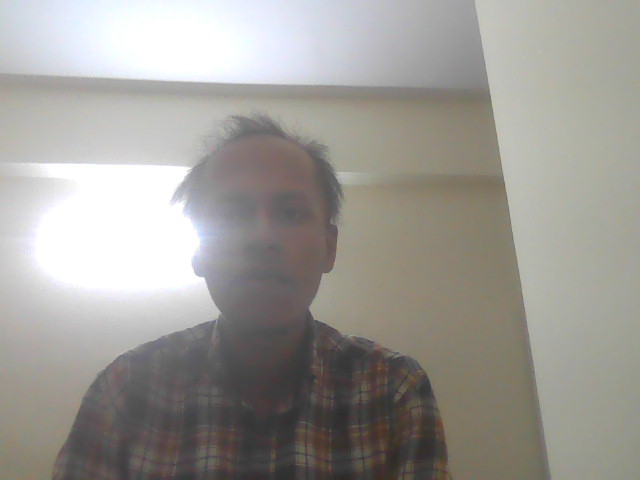

In [ ]:
import cv2
from IPython.display import display, clear_output
from PIL import Image
import time

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera error")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x,y,w,h) in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray,1.1,5)
        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(rgb)
    clear_output(wait=True)
    display(img)
    time.sleep(0.03)


In [3]:
import cv2

# Load Haarcascade classifiers
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)
smile_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_smile.xml"
)

# Start webcam
cap = cv2.VideoCapture(0)

print("Press 'q' to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera not accessible")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        # Detect eyes
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

        # Detect smile
        smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20)
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

    cv2.imshow("Face, Eye & Smile Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Press 'q' to quit


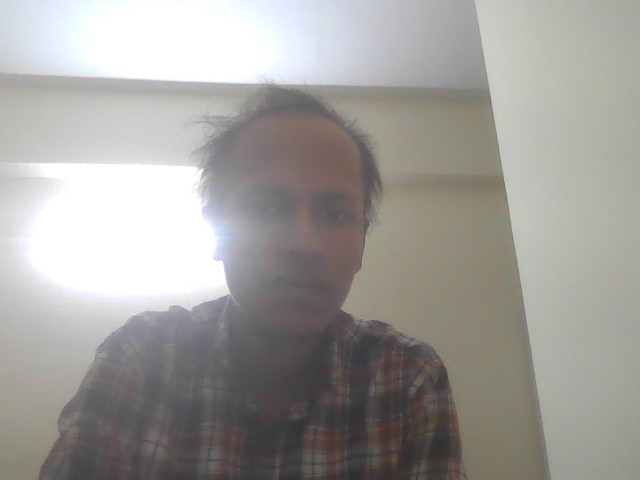

In [ ]:
import cv2
from IPython.display import display, clear_output
from PIL import Image
import time

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_smile.xml")

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera error")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x,y,w,h) in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray,1.1,5)
        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

        smiles = smile_cascade.detectMultiScale(roi_gray,1.8,20)
        for (sx,sy,sw,sh) in smiles:
            cv2.rectangle(roi_color,(sx,sy),(sx+sw,sy+sh),(0,0,255),2)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(rgb)
    clear_output(wait=True)
    display(img)
    time.sleep(0.03)


In [5]:
b=44
b


44

In [7]:
type(b)

int

In [9]:
b

44

In [11]:
b

44

In [13]:
b

44

In [15]:
b

44

In [17]:
b

44

In [19]:
b

44

In [21]:
b

44